# **Stage 1: Data Collection and Preprocessing**
---

**Objective:** This notebook implements the data collection pipeline for our JEPA World Model project. We collect episodes from the CartPole-v1 Gymnasium environment, capturing RGB pixel observations along with actions, rewards, and termination flags.

**Preprocessing:** Following [World Models](https://worldmodels.github.io/) (Ha & Schmidhuber, 2018), each raw 400×600 frame is cropped to the region where the cart and pole can appear and resized to **64×64**. This keeps the full dataset at a few GB instead of ~180 GB.

**What we'll do:**
1. Check if dataset already exists (skip collection if yes)
2. Understand the CartPole-v1 environment and its observation space
3. Collect episodes using parallel processing, one compressed `.npz` file per episode
4. Consolidate the episode files into a single HDF5 dataset
5. Visualize and analyze the collected data

**Output:** A consolidated HDF5 dataset (`data/vae/vae_data.h5`) ready for training our VAE encoder in the next stage.

## **Setup and Imports**
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import our data collection pipeline
from jepacartpole.data_prep import (
    setup_pygame_headless,
    create_cartpole_env,
    preprocess_frame,
    collect_data,
    merge_episode_files,
    check_dataset_exists,
    plot_random_samples,
    plot_episode_sequence,
    plot_dataset_statistics,
    print_dataset_summary
)
from jepacartpole.data_prep.environment import CROP_TOP, CROP_BOTTOM
from jepacartpole.utils import get_data_dir, get_results_dir

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print("Setup complete!")

Setup complete!


## **Configuration**
---

Configure data collection parameters and paths:

In [2]:
# Data collection parameters
NUM_EPISODES = 500       # Total number of episodes to collect
STEPS_PER_EPISODE = 500  # Fixed length of each episode
ACTION_INTERVAL = 20     # Steps between action changes
SEED = 42                # Episode i uses seed SEED + i

# Directory paths
RAW_DATA_DIR = get_data_dir('raw')
VAE_DATA_DIR = get_data_dir('vae')
OUTPUT_FILE = VAE_DATA_DIR / 'vae_data.h5'

print(f"Configuration:")
print(f"  Episodes: {NUM_EPISODES}")
print(f"  Steps per episode: {STEPS_PER_EPISODE}")
print(f"  Total frames: {NUM_EPISODES * STEPS_PER_EPISODE:,}")
print(f"  Episode files: {RAW_DATA_DIR}")
print(f"  Output file: {OUTPUT_FILE}")

Configuration:
  Episodes: 500
  Steps per episode: 500
  Total frames: 250,000
  Episode files: /teamspace/studios/this_studio/jepa_cart_pole/data/raw
  Output file: /teamspace/studios/this_studio/jepa_cart_pole/data/vae/vae_data.h5


## **Check for Existing Dataset**
---

Before collecting data, check if the final dataset already exists. If it does, we skip collection to save time and resources.

In [3]:
print("Checking for existing dataset...\n")

dataset_exists = check_dataset_exists(str(OUTPUT_FILE), verbose=True)

if dataset_exists:
    print("\n⏭️  Skipping data collection - dataset already exists!")
    print("   To recollect data, delete the file and rerun this notebook.")
    SKIP_COLLECTION = True
else:
    print("\n▶️  No existing dataset found - will proceed with collection")
    SKIP_COLLECTION = False

Checking for existing dataset...

✅ Found existing dataset: /teamspace/studios/this_studio/jepa_cart_pole/data/vae/vae_data.h5
   Episodes: 500
   Steps per episode: 500
   File size: 2931.95 MB

⏭️  Skipping data collection - dataset already exists!
   To recollect data, delete the file and rerun this notebook.


## **1. Understanding the CartPole-v1 Environment**
---

The [CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment from Gymnasium provides a classic reinforcement learning problem first described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077) (1983).

### **Task Description**
A pole is attached by an un-actuated joint to a cart moving along a frictionless track. The goal is to keep the pole balanced upright by applying forces to the cart.

### **Action Space** (Discrete)
- **0**: Push cart to the left
- **1**: Push cart to the right

### **Reward Structure**
A reward of +1 is given for every step the pole remains upright, including the termination step. Episodes can last up to 500 steps (in CartPole-v1), with a threshold of 475 for considering the problem "solved".

### **Observation Space**
Originally, CartPole provides a 4-dimensional state vector:
- Cart position
- Cart velocity  
- Pole angle
- Pole angular velocity

**For our JEPA world model**, we modify the environment to provide **pixel observations** instead, using the `AddRenderObservation` wrapper. This gives us 400×600 RGB images, which is what a vision-based model would see.

### **Frame Preprocessing**
Like World Models, we do not store raw renders. Each frame is:
1. **Cropped** to rows `CROP_TOP:CROP_BOTTOM` (150–330), the band where the cart and pole can appear (the rest is white background)
2. **Resized** to 64×64 with area interpolation

This is applied inside the environment (`create_cartpole_env(preprocess=True)`), so every observation the pipeline sees is already 64×64×3.

In [4]:
if not SKIP_COLLECTION:
    # Setup pygame for headless rendering
    setup_pygame_headless()

    # Raw environment, to show what is being cropped
    env = create_cartpole_env(preprocess=False)
    print(f"Raw observation space: {env.observation_space}")
    print(f"Action space: {env.action_space}")

    raw_obs, _ = env.reset(seed=SEED)
    obs = preprocess_frame(raw_obs)
    env.close()

    print(f"\nPreprocessed observation shape: {obs.shape}")
    print(f"Preprocessed observation dtype: {obs.dtype}")

    # Visualize raw frame (with crop band) and preprocessed frame
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.5, 1]})
    axes[0].imshow(raw_obs)
    axes[0].axhline(CROP_TOP, color='red', linestyle='--')
    axes[0].axhline(CROP_BOTTOM, color='red', linestyle='--')
    axes[0].set_title('Raw observation (400×600×3) with crop band', fontsize=14)
    axes[0].axis('off')
    axes[1].imshow(obs)
    axes[1].set_title('Preprocessed observation (64×64×3)', fontsize=14)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping environment demo - dataset already exists")

Skipping environment demo - dataset already exists


## **2. Parallel Data Collection**
---

### **Collection Strategy**

1. **Parallelization**: Distribute workload across all available CPU cores

2. **Episode Generation**: Each episode runs for a fixed number of steps (500). If the pole falls before completion, the environment automatically resets and continues (marked in `dones`).

3. **Action Policy**: Random action policy that changes every 20 steps, creating diverse trajectories. Each episode has its own seed, so the dataset is reproducible.

4. **Storage**: As in World Models, each episode is written to its own compressed `.npz` file in `data/raw/`. Episodes that already exist are skipped, so an interrupted collection can be resumed by re-running the cell.

In [5]:
%%time

if not SKIP_COLLECTION:
    collect_data(
        num_episodes=NUM_EPISODES,
        max_steps=STEPS_PER_EPISODE,
        output_dir=RAW_DATA_DIR,
        action_interval=ACTION_INTERVAL,
        grayscale=False,
        seed=SEED,
        verbose=True
    )
else:
    print("⏭️  Skipping data collection - dataset already exists")

⏭️  Skipping data collection - dataset already exists
CPU times: user 81 µs, sys: 0 ns, total: 81 µs
Wall time: 113 µs


## **3. Consolidating the Dataset**
---

Now we merge the episode files into a single consolidated HDF5 dataset.

### **Consolidated Dataset Structure**

```
vae_data.h5
├── images:  uint8   (num_episodes, max_steps, 64, 64, 3)  # Preprocessed RGB observations
├── actions: float32 (num_episodes, max_steps)             # Actions taken
├── rewards: float32 (num_episodes, max_steps)             # Rewards received
└── dones:   bool    (num_episodes, max_steps)             # Episode termination flags
```

The crop rows and frame size are stored as file attributes.

The consolidation process:
1. Verifies data integrity (correct number of steps)
2. Writes to a single HDF5 file chunked by episode
3. Deletes the per-episode `.npz` files once the merged file is complete

In [6]:
%%time

# Only consolidate if final dataset doesn't exist
if not check_dataset_exists(str(OUTPUT_FILE), verbose=False):
    print("Starting dataset consolidation...\n")

    stats = merge_episode_files(
        episodes_dir=RAW_DATA_DIR,
        output_file=OUTPUT_FILE,
        max_steps=STEPS_PER_EPISODE,
        delete_temp_files=True,
        verbose=True
    )

    print(f"\n✅ Dataset consolidation completed!")
else:
    print("✅ Final dataset already exists - skipping consolidation")

✅ Final dataset already exists - skipping consolidation
CPU times: user 977 µs, sys: 0 ns, total: 977 µs
Wall time: 916 µs


## **4. Dataset Analysis and Visualization**
---

Now that we have our consolidated dataset, let's explore and visualize it to ensure data quality and understand its characteristics.

### **4.1 Dataset Summary**

First, let's print a comprehensive summary of the dataset:

In [7]:
print_dataset_summary(str(OUTPUT_FILE))

Dataset Summary: vae_data.h5

File Size: 2931.95 MB
File Path: /teamspace/studios/this_studio/jepa_cart_pole/data/vae/vae_data.h5

Dataset Structure:
  actions : float32  (500, 500)
  dones   : bool     (500, 500)
  images  : uint8    (500, 500, 64, 64, 3)
  rewards : float32  (500, 500)

Episode Information:
  Number of episodes: 500
  Steps per episode: 500
  Total frames: 250,000

Reward Statistics:
  Mean reward per step: 1.000
  Total reward per episode (mean): 500.0
  Total reward per episode (std): 0.0

Action Distribution:
  Left (0): 124,240 (49.7%)
  Right (1): 125,760 (50.3%)

Episode Terminations:
  Mean terminations per episode: 48.53
  Max terminations per episode: 53


### **4.2 Random Sample Visualization**

Let's visualize random frames from across the dataset to see the variety of states captured:

Figure saved to: /teamspace/studios/this_studio/jepa_cart_pole/results/data_prep/random_samples.png


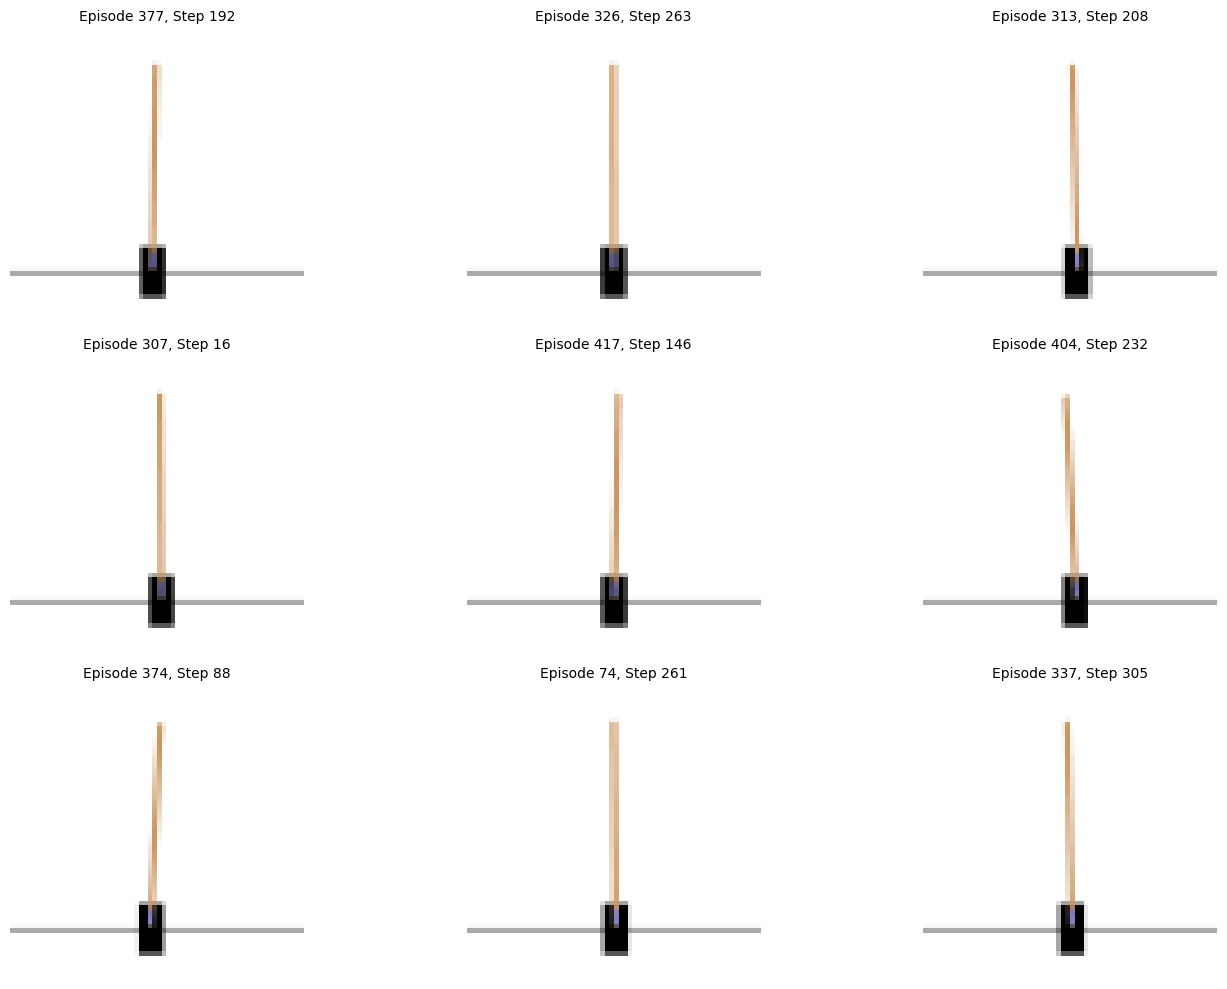

In [8]:
# Plot random samples
results_dir = get_results_dir('data_prep')
save_path = results_dir / 'random_samples.png'

fig = plot_random_samples(
    h5_path=str(OUTPUT_FILE),
    num_samples=9,
    figsize=(15, 10),
    save_path=str(save_path)
)
plt.show()

### **4.3 Episode Sequence Visualization**

To understand the temporal dynamics, let's visualize a sequence of frames from a single episode:

Figure saved to: /teamspace/studios/this_studio/jepa_cart_pole/results/data_prep/episode_sequence.png


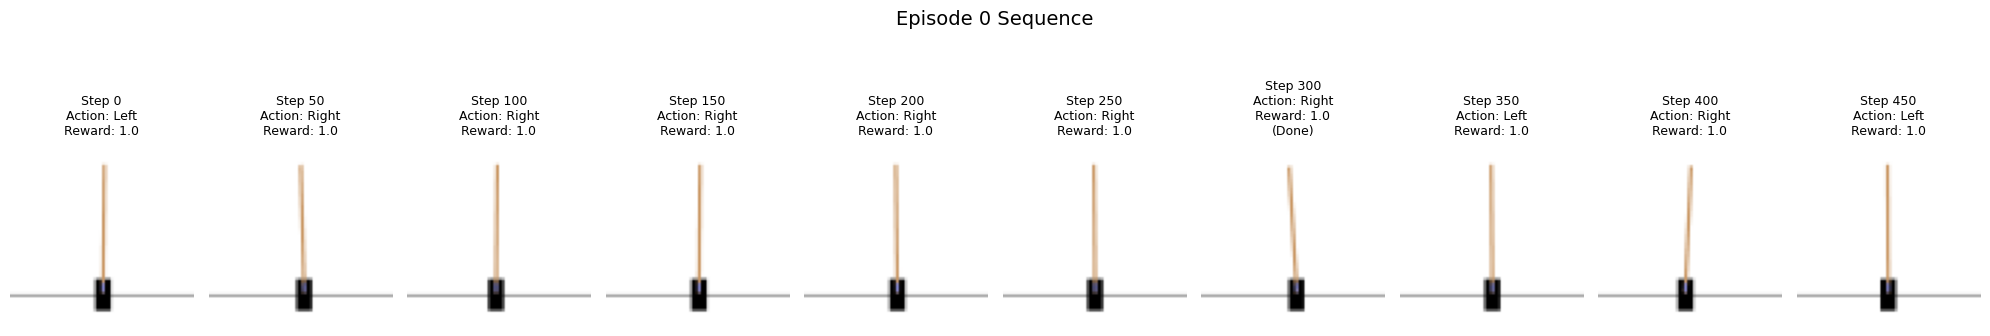

In [9]:
# Plot episode sequence
save_path = results_dir / 'episode_sequence.png'

fig = plot_episode_sequence(
    h5_path=str(OUTPUT_FILE),
    episode_idx=0,
    num_frames=10,
    step_interval=50,
    figsize=(20, 4),
    save_path=str(save_path)
)
plt.show()

Let's also look at a different episode to see variety in trajectories:

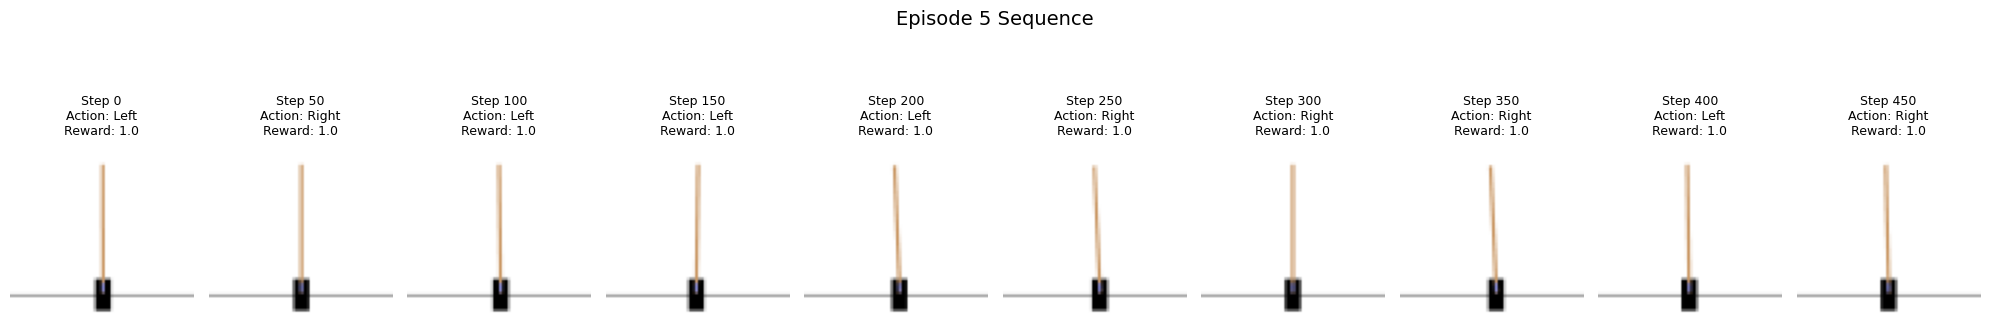

In [10]:
# Plot a different episode
fig = plot_episode_sequence(
    h5_path=str(OUTPUT_FILE),
    episode_idx=5,
    num_frames=10,
    step_interval=50,
    figsize=(20, 4)
)
plt.show()

### **4.4 Statistical Analysis**

Finally, let's examine the statistical properties of the dataset:

Figure saved to: /teamspace/studios/this_studio/jepa_cart_pole/results/data_prep/dataset_statistics.png


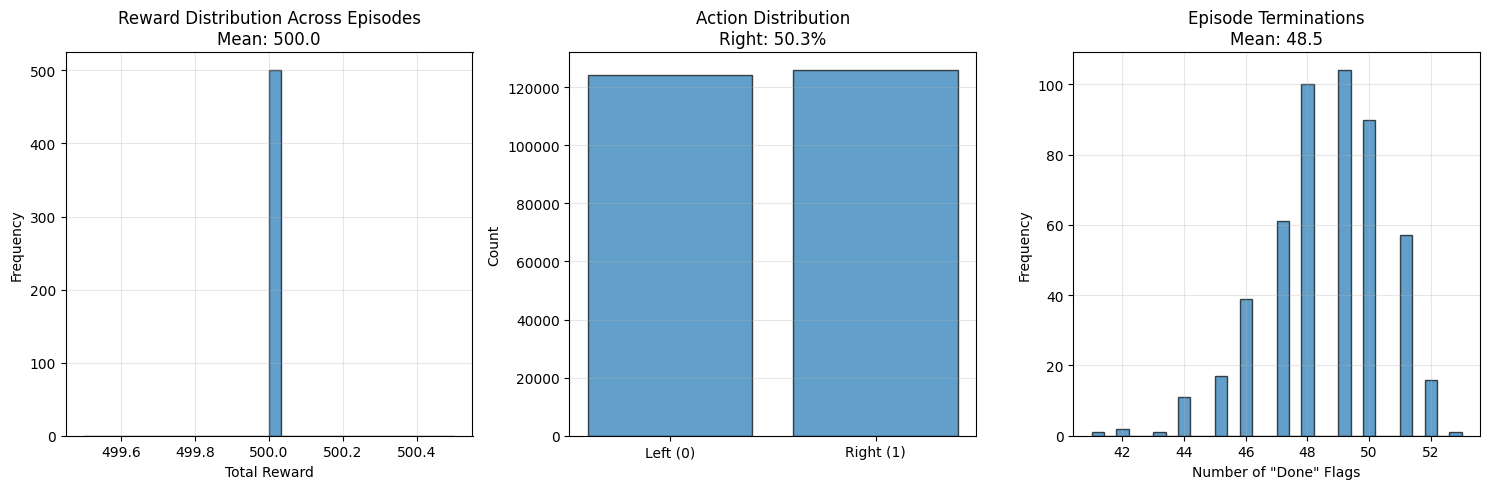

In [11]:
# Plot dataset statistics
save_path = results_dir / 'dataset_statistics.png'

fig = plot_dataset_statistics(
    h5_path=str(OUTPUT_FILE),
    figsize=(15, 5),
    save_path=str(save_path)
)
plt.show()

## **Summary and Next Steps**
---

### **What We Accomplished**

✓ Implemented smart dataset checking to avoid redundant collection

✓ Preprocessed frames to 64×64 following World Models

✓ Collected dataset using parallel processing, one compressed file per episode (resumable)

✓ Consolidated episode files into a single HDF5 dataset

✓ Verified data quality through visualization and statistical analysis

### **Dataset Characteristics**

- **Format**: HDF5 chunked by episode, uint8 images
- **Size**: ~3–4 GB for 500 episodes × 500 steps
- **Balance**: Random action policy ensures diverse state coverage
- **Quality**: Visual inspection confirms proper rendering and data integrity

### **Next Stage: VAE Training**

With our dataset ready, we can now proceed to **Stage 2: VAE Encoder Training** (`notebooks/2-vae/1-vae_training.ipynb`). In the next notebook, we will:

1. Train a Variational Autoencoder (VAE) to compress the 64×64×3 images into a compact latent representation
2. Evaluate the reconstruction quality
3. Explore the learned latent space
4. Prepare encoded latents for JEPA world model training

---

**Dataset Location**: `data/vae/vae_data.h5`

**Results Location**: `results/data_prep/`